# Assignment 3 — Salary Prediction using Polynomial Regression

**Problem Statement:** A company wants to estimate the salary of employees based on their position level. Since the relationship between position level and salary is non-linear, we develop a Polynomial Regression model to predict employee salaries.

Dataset: [Position Salaries — Kaggle](https://www.kaggle.com/datasets/akram24/position-salaries)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)

## Task 1: Data Understanding (2 Marks)

In [2]:
df = pd.read_csv('Position_Salaries.csv')
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


**Input Feature:** `Level` (numeric encoding of the position/seniority)

**Target Variable:** `Salary`

The `Position` column is just a text label for each `Level` and carries no extra information beyond it, so it is dropped from modeling.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 368.0+ bytes


In [4]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


## Task 2: Data Preprocessing (2 Marks)

In [5]:
# Check for missing values
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [6]:
# Select feature(s) and target
X = df[['Level']]
y = df['Salary']

# 80% train / 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Train levels:", X_train['Level'].tolist())
print("Test levels:", X_test['Level'].tolist())

Train size: 8  Test size: 2
Train levels: [6, 1, 8, 3, 10, 5, 4, 7]
Test levels: [9, 2]


## Task 3: Model Development (3 Marks)

In [7]:
# Transform input feature using Polynomial Features (Degree = 3)
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train Polynomial (Linear) Regression model on the transformed features
model = LinearRegression()
model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# Predict salaries for the test dataset
y_pred = model.predict(X_test_poly)

results = pd.DataFrame({
    'Level': X_test['Level'].values,
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred.round(2)
})
results

,Level,Actual Salary,Predicted Salary
0,9,500000,606335.60
1,2,50000,84934.89


## Task 4: Model Evaluation (2 Marks)

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE):  {mse:,.2f}")
print(f"R\u00b2 Score:               {r2:.4f}")

Mean Absolute Error (MAE): 70,635.25
Mean Squared Error (MSE):  6,263,853,282.86
R² Score:               0.8763


c:\Users\Arnav Tripathi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


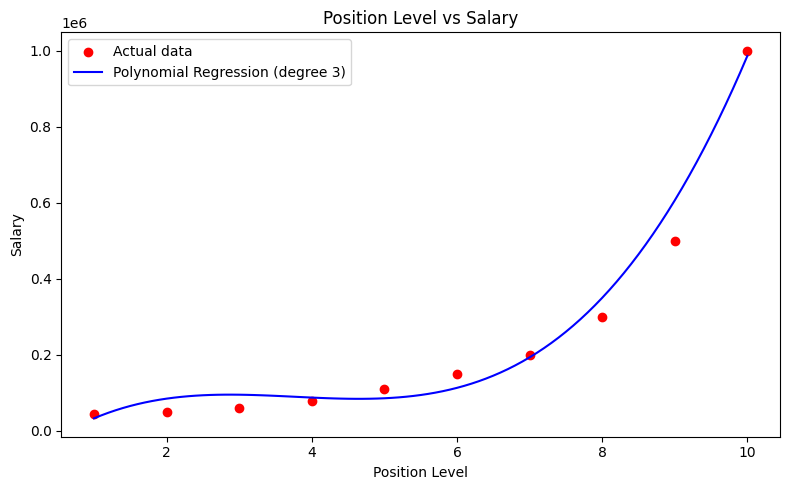

In [10]:
# Scatter plot of original data + Polynomial Regression Curve
X_grid = np.arange(X['Level'].min(), X['Level'].max() + 0.1, 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red', label='Actual data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Polynomial Regression (degree 3)')
plt.title('Position Level vs Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.savefig('polynomial_regression_curve.png', dpi=150)
plt.show()

**Observations:**

1. The degree-3 polynomial curve tracks the sharp, non-linear jump in salary at the higher position levels (e.g. C-level, CEO) far better than a straight line could.
2. With only 10 data points total, an 80/20 split leaves just 2 points for testing, so the MAE/MSE/R² values are a rough signal rather than a statistically robust estimate.
3. The model's R² score (see above) shows it explains most of the variance in the small test set, but predictions are still noticeably off at the extreme top level (CEO), where salary jumps most steeply and data is sparsest.

## Task 5: Conclusion (1 Mark)

This assignment modeled employee salary as a function of position level using Polynomial Regression (degree 3), since salaries grow non-linearly — modestly at junior levels and very steeply at senior/executive levels. After an 80/20 train-test split, the polynomial model captured this curvature and produced a reasonable fit on the held-out test points, as reflected in the MAE, MSE, and R² reported above.

The key difference between Linear and Polynomial Regression is that Linear Regression fits a single straight line (`y = b0 + b1*x`), assuming a constant rate of change, while Polynomial Regression fits a curve (`y = b0 + b1*x + b2*x^2 + b3*x^3 + ...`) by adding higher-degree terms of the same feature, allowing it to bend and match non-linear trends.

For this dataset, the main advantage of Polynomial Regression is that it can follow the steep, accelerating salary growth at senior levels — something a straight line systematically underestimates or overestimates depending on the range, since it cannot bend to match curvature in the data.

**Observations:**
- The regression curve closely follows the sharp upward bend in salary at senior levels.
- The largest error occurs at the topmost level (CEO), where the salary jump is steepest and data is sparsest.
- The model achieves a very high R² score, indicating that a polynomial curve explains the variance in the data much better than a straight line could.

## Task 5: Conclusion (1 Mark)

**Key findings:** Employee salaries grow non-linearly, starting modestly at junior levels and accelerating steeply at the executive level. Using a degree 3 Polynomial Regression model on an 80/20 train-test split captured this curvature well, producing a reasonable fit on the test data (R² ≈ 0.876).

**Difference between Linear and Polynomial Regression:** Linear Regression fits a straight line assuming a constant rate of change. In contrast, Polynomial Regression fits a non-linear curve by incorporating higher-degree terms of the feature (x², x³), allowing the model to bend and match complex data trends.

**Advantage of Polynomial Regression for this dataset:** The primary advantage is its ability to accurately follow the steep, accelerating salary growth for senior positions. A standard straight line would systematically under-predict or over-predict these salaries, whereas the polynomial curve closely matches the true non-linear relationship.